In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, project_root)

# Create output directories
os.makedirs(os.path.join(project_root, "figures"), exist_ok=True)
os.makedirs(os.path.join(project_root, "data", "processed"), exist_ok=True)

# Load preprocessed data from Phase 1
processed_dir = os.path.join(project_root, "data", "processed")

X_train = pickle.load(open(os.path.join(processed_dir, "X_train_scaled.pkl"), "rb"))
X_test = pickle.load(open(os.path.join(processed_dir, "X_test_scaled.pkl"), "rb"))
y_train = pickle.load(open(os.path.join(processed_dir, "y_train.pkl"), "rb"))
y_test = pickle.load(open(os.path.join(processed_dir, "y_test.pkl"), "rb"))
target_encoder = pickle.load(open(os.path.join(processed_dir, "target_encoder.pkl"), "rb"))

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {list(target_encoder.classes_)}")
print(f"\nFeature names ({len(X_train.columns)}):")
print(list(X_train.columns))

X_train: (98493, 83)
X_test:  (24624, 83)
Classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'Metasploit_Brute_Force_SSH', 'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Thing_Speak', 'Wipro_bulb']

Feature names (83):
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd

In [2]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on full 83-feature training set
# NOTE: We're using RF here as a FEATURE SELECTION TOOL, not as our final classifier.
# RF assigns an "importance" score to each feature based on how much it reduces
# impurity (Gini) across all decision trees. Features that split classes well get high scores.

print("Training Random Forest for feature importance ranking...")


rf = RandomForestClassifier(
    n_estimators=200,       # 200 trees — more trees = more stable importance estimates
    random_state=42,
    n_jobs=-1,              # Use all CPU cores for speed
    class_weight="balanced" # Account for imbalance so rare classes influence importance too
)

rf.fit(X_train, y_train)

# Extract importances and create a ranked DataFrame
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Add rank and cumulative importance
feature_importance_df["rank"] = range(1, len(feature_importance_df) + 1)
feature_importance_df["cumulative"] = feature_importance_df["importance"].cumsum()

print("Top 20 features by Random Forest importance:\n")
print(feature_importance_df.head(20).to_string(index=False))
print(f"\nTop 10 features capture {feature_importance_df.iloc[9]['cumulative']:.1%} of total importance")
print(f"Top 20 features capture {feature_importance_df.iloc[19]['cumulative']:.1%} of total importance")
print(f"Top 30 features capture {feature_importance_df.iloc[29]['cumulative']:.1%} of total importance")

Training Random Forest for feature importance ranking...
Top 20 features by Random Forest importance:

              feature  importance  rank  cumulative
 fwd_last_window_size    0.046317     1    0.046317
   fwd_URG_flag_count    0.043730     2    0.090047
            id.resp_p    0.043366     3    0.133413
  fwd_header_size_min    0.038665     4    0.172078
   fwd_PSH_flag_count    0.037009     5    0.209087
         flow_iat.min    0.035921     6    0.245007
flow_pkts_payload.avg    0.033459     7    0.278467
flow_pkts_payload.max    0.030617     8    0.309084
 fwd_pkts_payload.avg    0.030015     9    0.339098
 fwd_pkts_payload.max    0.027979    10    0.367077
  fwd_header_size_tot    0.026377    11    0.393454
  flow_FIN_flag_count    0.025026    12    0.418481
  fwd_header_size_max    0.024367    13    0.442848
flow_pkts_payload.tot    0.023707    14    0.466555
     bwd_pkts_per_sec    0.023304    15    0.489859
 fwd_pkts_payload.tot    0.022849    16    0.512708
 fwd_init_win

Saved to /Users/mahip/Projects/CS-6140-Project-IoT-Intrusion-Detection/figures/feature_importance.png


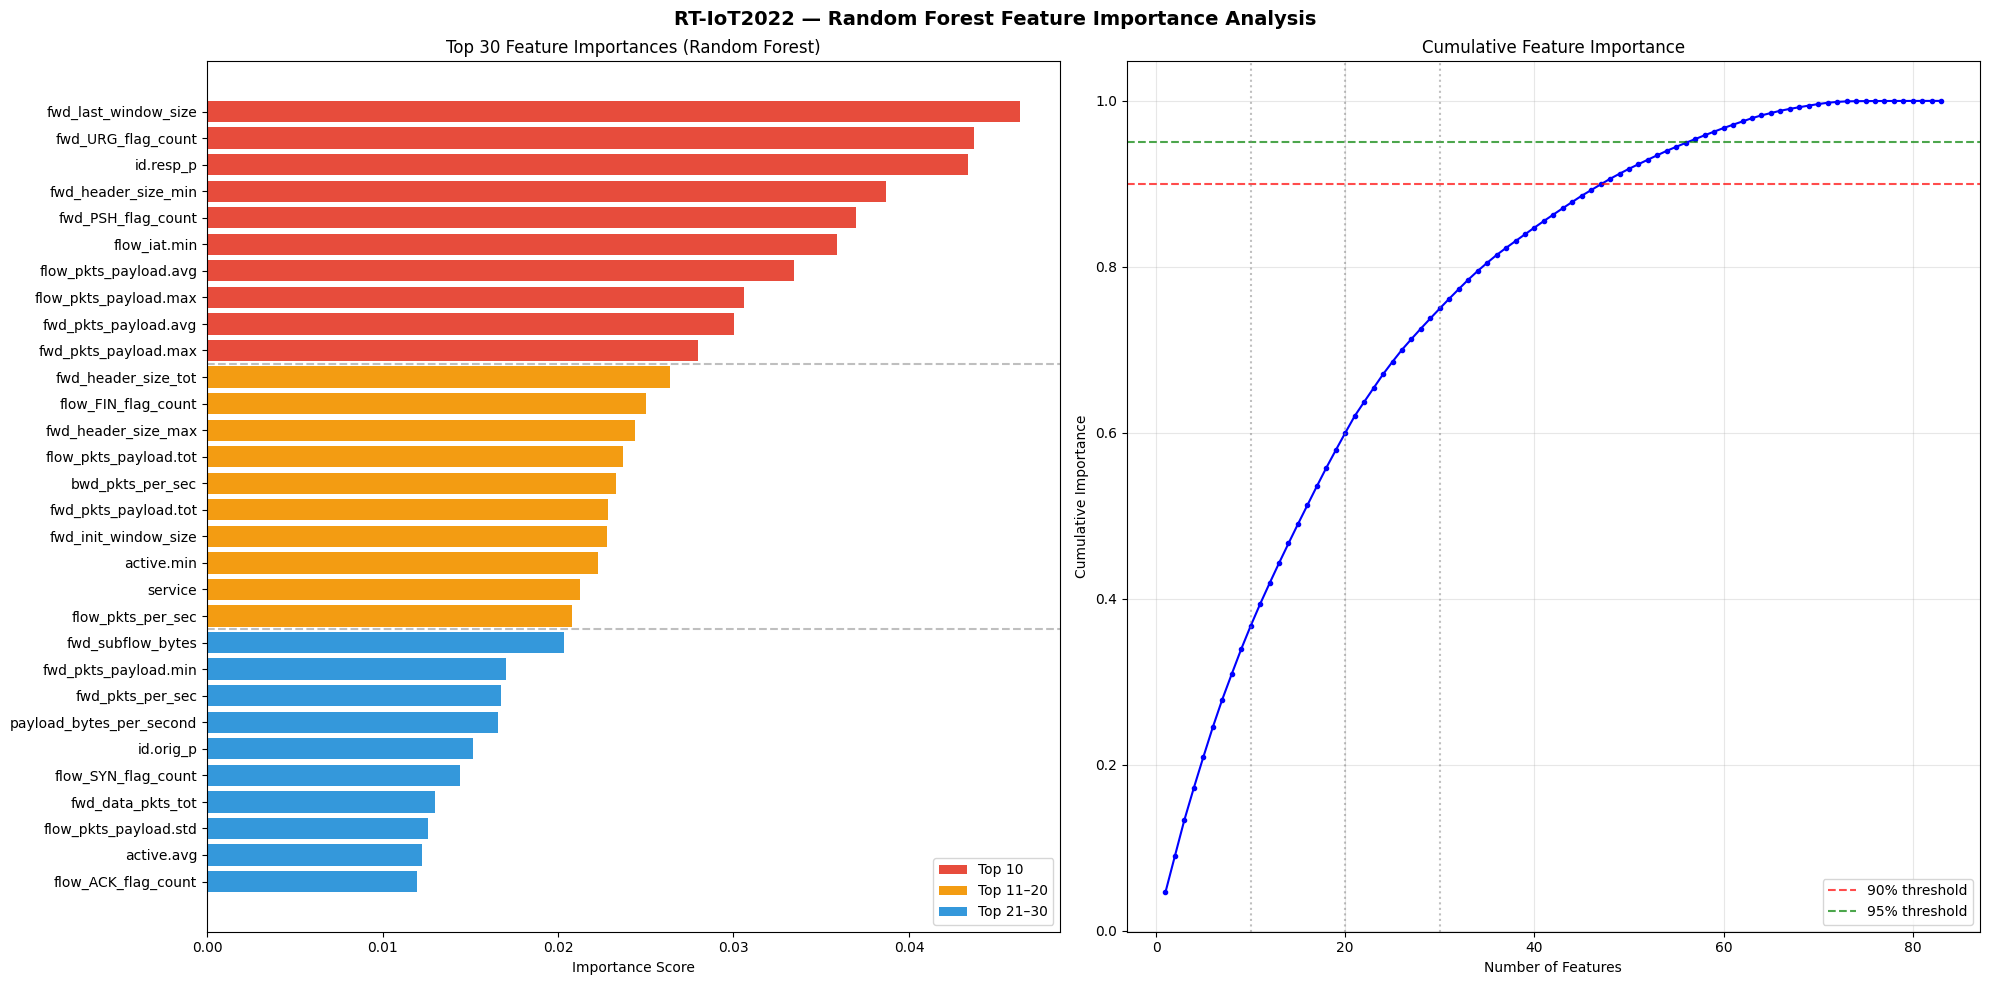

In [3]:
# Plot top 30 feature importances — this becomes a key figure in your report

top30 = feature_importance_df.head(30)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Bar chart of top 30 feature importances
ax1 = axes[0]
colors = ["#e74c3c" if i < 10 else "#f39c12" if i < 20 else "#3498db" for i in range(30)]
bars = ax1.barh(top30["feature"][::-1], top30["importance"][::-1], color=colors[::-1])
ax1.set_xlabel("Importance Score")
ax1.set_title("Top 30 Feature Importances (Random Forest)")
ax1.axhline(y=19.5, color="gray", linestyle="--", alpha=0.5, label="Top 10 cutoff")
ax1.axhline(y=9.5, color="gray", linestyle="--", alpha=0.5, label="Top 20 cutoff")

# Add legend for color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Top 10"),
    Patch(facecolor="#f39c12", label="Top 11–20"),
    Patch(facecolor="#3498db", label="Top 21–30"),
]
ax1.legend(handles=legend_elements, loc="lower right")

# Right: Cumulative importance curve
ax2 = axes[1]
ax2.plot(range(1, 84), feature_importance_df["cumulative"], "b-o", markersize=3)
ax2.axhline(y=0.90, color="red", linestyle="--", alpha=0.7, label="90% threshold")
ax2.axhline(y=0.95, color="green", linestyle="--", alpha=0.7, label="95% threshold")
ax2.axvline(x=10, color="gray", linestyle=":", alpha=0.5)
ax2.axvline(x=20, color="gray", linestyle=":", alpha=0.5)
ax2.axvline(x=30, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Number of Features")
ax2.set_ylabel("Cumulative Importance")
ax2.set_title("Cumulative Feature Importance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("RT-IoT2022 — Random Forest Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(project_root, "figures", "feature_importance.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved to {save_path}")
plt.show()

In [4]:
# Create feature subsets using the RF importance ranking
# We select the top 10, 20, and 30 column NAMES, then filter both train and test
# to keep only those columns. Test data uses the SAME columns — no information leakage.

top10_features = feature_importance_df.head(10)["feature"].tolist()
top20_features = feature_importance_df.head(20)["feature"].tolist()
top30_features = feature_importance_df.head(30)["feature"].tolist()

# Filter train and test to keep only selected columns
X_train_top10 = X_train[top10_features]
X_test_top10 = X_test[top10_features]

X_train_top20 = X_train[top20_features]
X_test_top20 = X_test[top20_features]

X_train_top30 = X_train[top30_features]
X_test_top30 = X_test[top30_features]

# Print summary
print("Feature Subsets Created:\n")
print(f"Top 10: {X_train_top10.shape} — captures {feature_importance_df.iloc[9]['cumulative']:.1%} importance")
print(f"  Features: {top10_features}\n")
print(f"Top 20: {X_train_top20.shape} — captures {feature_importance_df.iloc[19]['cumulative']:.1%} importance")
print(f"  Features: {top20_features}\n")
print(f"Top 30: {X_train_top30.shape} — captures {feature_importance_df.iloc[29]['cumulative']:.1%} importance")
print(f"  Features: {top30_features}\n")
print(f"Full:   {X_train.shape} — 100% importance")

Feature Subsets Created:

Top 10: (98493, 10) — captures 36.7% importance
  Features: ['fwd_last_window_size', 'fwd_URG_flag_count', 'id.resp_p', 'fwd_header_size_min', 'fwd_PSH_flag_count', 'flow_iat.min', 'flow_pkts_payload.avg', 'flow_pkts_payload.max', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.max']

Top 20: (98493, 20) — captures 60.0% importance
  Features: ['fwd_last_window_size', 'fwd_URG_flag_count', 'id.resp_p', 'fwd_header_size_min', 'fwd_PSH_flag_count', 'flow_iat.min', 'flow_pkts_payload.avg', 'flow_pkts_payload.max', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.max', 'fwd_header_size_tot', 'flow_FIN_flag_count', 'fwd_header_size_max', 'flow_pkts_payload.tot', 'bwd_pkts_per_sec', 'fwd_pkts_payload.tot', 'fwd_init_window_size', 'active.min', 'service', 'flow_pkts_per_sec']

Top 30: (98493, 30) — captures 75.0% importance
  Features: ['fwd_last_window_size', 'fwd_URG_flag_count', 'id.resp_p', 'fwd_header_size_min', 'fwd_PSH_flag_count', 'flow_iat.min', 'flow_pkts_payload.avg', 

Components needed for 90% variance: 20
Components needed for 95% variance: 26
Components needed for 99% variance: 38

Saved to /Users/mahip/Projects/CS-6140-Project-IoT-Intrusion-Detection/figures/pca_variance.png


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


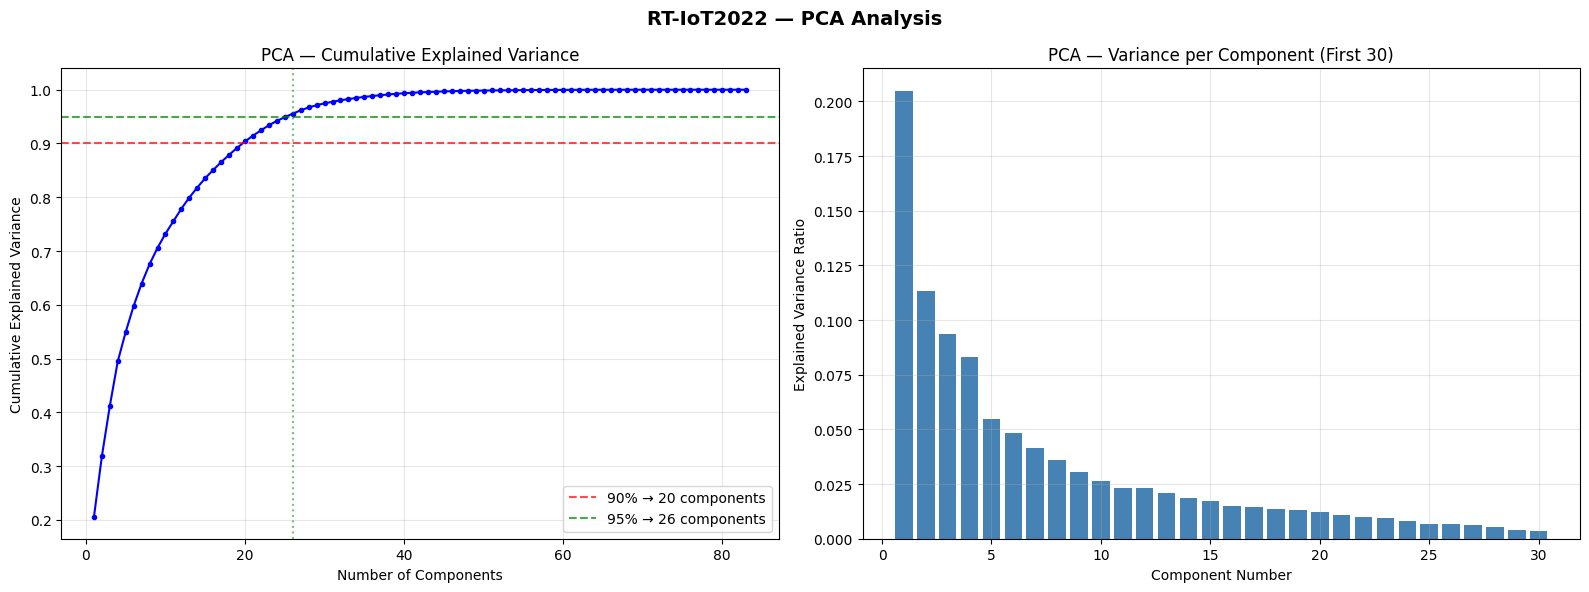


Applying PCA with 26 components (95% variance)...
X_train_pca: (98493, 26)
X_test_pca:  (24624, 26)
Reduced from 83 features → 26 components while keeping 95% of information


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed =

In [5]:
from sklearn.decomposition import PCA

# --- Step 1: Fit PCA on ALL 83 components first to see explained variance ---
# PCA finds new "directions" (components) in the data that capture the most variation.
# Unlike RF feature selection which KEEPS original columns, PCA creates BRAND NEW columns
# that are combinations of the originals. Component 1 captures the most variance,
# Component 2 captures the second most, and so on.

pca_full = PCA(n_components=83, random_state=42)
pca_full.fit(X_train)  # Fit on training data ONLY

# Cumulative explained variance — how much total info each component adds
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find how many components needed for 90% and 95% variance
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

# --- Step 2: Plot cumulative explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Cumulative variance
ax1 = axes[0]
ax1.plot(range(1, 84), cumulative_variance, "b-o", markersize=3)
ax1.axhline(y=0.90, color="red", linestyle="--", alpha=0.7, label=f"90% → {n_90} components")
ax1.axhline(y=0.95, color="green", linestyle="--", alpha=0.7, label=f"95% → {n_95} components")
ax1.axvline(x=n_95, color="green", linestyle=":", alpha=0.5)
ax1.set_xlabel("Number of Components")
ax1.set_ylabel("Cumulative Explained Variance")
ax1.set_title("PCA — Cumulative Explained Variance")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Individual variance per component (scree plot)
ax2 = axes[1]
ax2.bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color="steelblue")
ax2.set_xlabel("Component Number")
ax2.set_ylabel("Explained Variance Ratio")
ax2.set_title("PCA — Variance per Component (First 30)")
ax2.grid(True, alpha=0.3)

plt.suptitle("RT-IoT2022 — PCA Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(project_root, "figures", "pca_variance.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"\nSaved to {save_path}")
plt.show()

# --- Step 3: Apply PCA with 95% variance threshold ---
print(f"\nApplying PCA with {n_95} components (95% variance)...")
pca = PCA(n_components=n_95, random_state=42)

X_train_pca = pca.fit_transform(X_train)   # Fit on train, transform train
X_test_pca = pca.transform(X_test)          # Transform test using SAME fit

# Convert to DataFrames for consistency
pca_cols = [f"PC{i+1}" for i in range(n_95)]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols)

print(f"X_train_pca: {X_train_pca.shape}")
print(f"X_test_pca:  {X_test_pca.shape}")
print(f"Reduced from 83 features → {n_95} components while keeping 95% of information")

In [6]:
# Check for problematic values in the scaled data
print("Checking X_train for issues...\n")

print(f"Any NaN values:      {X_train.isnull().any().any()}")
print(f"Any infinite values: {np.isinf(X_train.values).any()}")
print(f"Max value:           {X_train.values.max():.2f}")
print(f"Min value:           {X_train.values.min():.2f}")

# Find columns with extreme values
print("\nColumns with extreme values (max > 1000 after scaling):")
for col in X_train.columns:
    col_max = X_train[col].abs().max()
    if col_max > 1000:
        print(f"  {col}: max abs = {col_max:.2f}")

# Check PCA output for NaNs
print(f"\nPCA output has NaN: {X_train_pca.isnull().any().any()}")
print(f"PCA output has Inf: {np.isinf(X_train_pca.values).any()}")

Checking X_train for issues...

Any NaN values:      False
Any infinite values: False
Max value:           289.88
Min value:           -3.70

Columns with extreme values (max > 1000 after scaling):

PCA output has NaN: False
PCA output has Inf: False


In [7]:
# Save all feature subsets so Mahip can load them directly for SMOTE + model training.
# Each subset has a train and test version — both use the same features/components.

processed_dir = os.path.join(project_root, "data", "processed")

# Top 10
pickle.dump(X_train_top10, open(os.path.join(processed_dir, "X_train_top10.pkl"), "wb"))
pickle.dump(X_test_top10, open(os.path.join(processed_dir, "X_test_top10.pkl"), "wb"))

# Top 20
pickle.dump(X_train_top20, open(os.path.join(processed_dir, "X_train_top20.pkl"), "wb"))
pickle.dump(X_test_top20, open(os.path.join(processed_dir, "X_test_top20.pkl"), "wb"))

# Top 30
pickle.dump(X_train_top30, open(os.path.join(processed_dir, "X_train_top30.pkl"), "wb"))
pickle.dump(X_test_top30, open(os.path.join(processed_dir, "X_test_top30.pkl"), "wb"))

# PCA
pickle.dump(X_train_pca, open(os.path.join(processed_dir, "X_train_pca.pkl"), "wb"))
pickle.dump(X_test_pca, open(os.path.join(processed_dir, "X_test_pca.pkl"), "wb"))

# Save feature importance ranking and feature lists (useful for report/analysis)
pickle.dump(feature_importance_df, open(os.path.join(processed_dir, "feature_importance_df.pkl"), "wb"))
pickle.dump({"top10": top10_features, "top20": top20_features, "top30": top30_features},
            open(os.path.join(processed_dir, "feature_lists.pkl"), "wb"))

# Print summary
print("All feature subsets saved to data/processed/\n")
print(f"{'File':<30} {'Shape':<20} {'Size (MB)':>10}")
print("-" * 62)
files_to_check = [
    ("X_train_top10.pkl", X_train_top10),
    ("X_test_top10.pkl", X_test_top10),
    ("X_train_top20.pkl", X_train_top20),
    ("X_test_top20.pkl", X_test_top20),
    ("X_train_top30.pkl", X_train_top30),
    ("X_test_top30.pkl", X_test_top30),
    ("X_train_pca.pkl", X_train_pca),
    ("X_test_pca.pkl", X_test_pca),
]
for fname, data in files_to_check:
    fpath = os.path.join(processed_dir, fname)
    size = os.path.getsize(fpath) / (1024 * 1024)
    print(f"{fname:<30} {str(data.shape):<20} {size:>9.1f}")

print(f"\n Feature selection complete!")

All feature subsets saved to data/processed/

File                           Shape                 Size (MB)
--------------------------------------------------------------
X_train_top10.pkl              (98493, 10)                8.3
X_test_top10.pkl               (24624, 10)                2.1
X_train_top20.pkl              (98493, 20)               15.8
X_test_top20.pkl               (24624, 20)                3.9
X_train_top30.pkl              (98493, 30)               23.3
X_test_top30.pkl               (24624, 30)                5.8
X_train_pca.pkl                (98493, 26)               19.5
X_test_pca.pkl                 (24624, 26)                4.9

 Feature selection complete!
